In [1]:
mode = "colab" # change this to "local" if you are on your own computer

if mode == "local":
    import models
elif mode == "colab":
    import requests
    url = 'https://github.com/ahmadianlab/gg3_nda/blob/main/models.py?raw=true'
    r = requests.get(url)
    with open('models.py', 'w') as f:
        f.write(r.text)
    import models
else:
    raise Exception("mode must be either local or colab")

In [2]:
import numpy as np
import numpy.random as npr


def lo_histogram(x, bins):
    """
    Left-open version of np.histogram with left-open bins covering the interval (left_edge, right_edge]
    (np.histogram does the opposite and treats bins as right-open.)
    Input & output behaviour is exactly the same as np.histogram
    """
    out = np.histogram(-x, -bins[::-1])
    return out[0][::-1], out[1:]


def gamma_isi_point_process(rate, shape):
    """
    Simulates (1 trial of) a sub-poisson point process (with underdispersed inter-spike intervals relative to Poisson)
    :param rate: time-series giving the mean spike count (firing rate * dt) in different time bins (= time steps)
    :param shape: shape parameter of the gamma distribution of ISI's
    :return: vector of spike counts with same shape as "rate".
    """
    sum_r_t = np.hstack((0, np.cumsum(rate)))
    gs = np.zeros(2)
    while gs[-1] < sum_r_t[-1]:
        gs = np.cumsum( npr.gamma(shape, 1 / shape, size=(2 + int(2 * sum_r_t[-1]),)) )
    y, _ = lo_histogram(gs, sum_r_t)

    return y



class StepModel():
    """
    Simulator of the Stepping Model of Latimer et al. Science 2015.
    """
    def __init__(self, m=50, r=10, x0=0.2, Rh=50, isi_gamma_shape=None, Rl=None, dt=None):
        """
        Simulator of the Stepping Model of Latimer et al. Science 2015.
        :param m: mean jump time (in # of time-steps). This is the mean parameter of the Negative Binomial distribution
                  of jump (stepping) time
        :param r: parameter r ("# of successes") of the Negative Binomial (NB) distribution of jump (stepping) time
                  (Note that it is more customary to parametrise the NB distribution by its parameter p and r,
                  instead of m and r, where p is so-called "probability of success" (see Wikipedia). The two
                  parametrisations are equivalent and one can go back-and-forth via: m = r (1-p)/p and p = r / (m + r).)
        :param x0: determines the pre-jump firing rate, via  R_pre = x0 * Rh (see below for Rh)
        :param Rh: firing rate of the "up" state (the same as the post-jump state in most of the project tasks)
        :param isi_gamma_shape: shape parameter of the Gamma distribution of inter-spike intervals.
                            see https://en.wikipedia.org/wiki/Gamma_distribution
        :param Rl: firing rate of the post-jump "down" state (rarely used)
        :param dt: real time duration of time steps in seconds (only used for converting rates to units of inverse time-step)
        """
        self.m = m
        self.r = r
        self.x0 = x0

        self.p = r / (m + r)

        self.Rh = Rh
        if Rl is not None:
            self.Rl = Rl

        self.isi_gamma_shape = isi_gamma_shape
        self.dt = dt


    @property
    def params(self):
        return self.m, self.r, self.x0

    @property
    def fixed_params(self):
        return self.Rh, self.Rl


    def emit(self, rate):
        """
        emit spikes based on rates
        :param rate: firing rate sequence, r_t, possibly in many trials. Shape: (Ntrials, T)
        :return: spike train, n_t, as an array of shape (Ntrials, T) containing integer spike counts in different
                 trials and time bins.
        """
        if self.isi_gamma_shape is None:
            # poisson spike emissions
            y = npr.poisson(rate * self.dt)
        else:
            # sub-poisson/underdispersed spike emissions
            y = gamma_isi_point_process(rate * self.dt, self.isi_gamma_shape)

        return y


    def simulate(self, Ntrials=1, T=100, get_rate=True):
        """
        :param Ntrials: (int) number of trials
        :param T: (int) duration of each trial in number of time-steps.
        :param get_rate: whether or not to return the rate time-series
        :return:
        spikes: shape = (Ntrial, T); spikes[j] gives the spike train, n_t, in trial j, as
                an array of spike counts in each time-bin (= time step)
        jumps:  shape = (Ntrials,) ; jumps[j] is the jump time (aka step time), tau, in trial j.
        rates:  shape = (Ntrial, T); rates[j] is the rate time-series, r_t, in trial j (returned only if get_rate=True)
        """
        # set dt (time-step duration in seconds) such that trial duration is always 1 second, regardless of T.
        dt = 1 / T
        self.dt = dt

        ts = np.arange(T)

        spikes, jumps, rates = [], [], []
        for tr in range(Ntrials):
            # sample jump time
            jump = npr.negative_binomial(self.r, self.p)
            jumps.append(jump)

            # first set rate at all times to pre-step rate
            rate = np.ones(T) * self.x0 * self.Rh
            # then set rates after jump to self.Rh
            rate[ts >= jump] = self.Rh
            rates.append(rate)

            spikes.append(self.emit(rate))

        if get_rate:
            return np.array(spikes), np.array(jumps), np.array(rates)
        else:
            return np.array(spikes), np.array(jumps)


class RampModel():
    """
    Simulator of the Ramping Model (aka Drift-Diffusion Model) of Latimer et al., Science (2015).
    """
    def __init__(self, beta=0.5, sigma=0.2, x0=.2, Rh=50, isi_gamma_shape=None, Rl=None, dt=None):
        """
        Simulator of the Ramping Model of Latimer et al. Science 2015.
        :param beta: drift rate of the drift-diffusion process
        :param sigma: diffusion strength of the drift-diffusion process.
        :param x0: average initial value of latent variable x[0]
        :param Rh: the maximal firing rate obtained when x_t reaches 1 (corresponding to the same as the post-step
                   state in most of the project tasks)
        :param isi_gamma_shape: shape parameter of the Gamma distribution of inter-spike intervals.
                            see https://en.wikipedia.org/wiki/Gamma_distribution
        :param Rl: Not implemented. Ignore.
        :param dt: real time duration of time steps in seconds (only used for converting rates to units of inverse time-step)
        """
        self.beta = beta
        self.sigma = sigma
        self.x0 = x0

        self.Rh = Rh
        if Rl is not None:
            self.Rl = Rl

        self.isi_gamma_shape = isi_gamma_shape
        self.dt = dt


    @property
    def params(self):
        return self.mu, self.sigma, self.x0

    @property
    def fixed_params(self):
        return self.Rh, self.Rl


    def f_io(self, xs, b=None):
        if b is None:
            return self.Rh * np.maximum(0, xs)
        else:
            return self.Rh * b * np.log(1 + np.exp(xs / b))


    def emit(self, rate):
        """
        emit spikes based on rates
        :param rate: firing rate sequence, r_t, possibly in many trials. Shape: (Ntrials, T)
        :return: spike train, n_t, as an array of shape (Ntrials, T) containing integer spike counts in different
                 trials and time bins.
        """
        if self.isi_gamma_shape is None:
            # poisson spike emissions
            y = npr.poisson(rate * self.dt)
        else:
            # sub-poisson/underdispersed spike emissions
            y = gamma_isi_point_process(rate * self.dt, self.isi_gamma_shape)

        return y


    def simulate(self, Ntrials=1, T=100, get_rate=True):
        """
        :param Ntrials: (int) number of trials
        :param T: (int) duration of each trial in number of time-steps.
        :param get_rate: whether or not to return the rate time-series
        :return:
        spikes: shape = (Ntrial, T); spikes[j] gives the spike train, n_t, in trial j, as
                an array of spike counts in each time-bin (= time step)
        xs:     shape = (Ntrial, T); xs[j] is the latent variable time-series x_t in trial j
        rates:  shape = (Ntrial, T); rates[j] is the rate time-series, r_t, in trial j (returned only if get_rate=True)
        """
        # set dt (time-step duration in seconds) such that trial duration is always 1 second, regardless of T.
        dt = 1 / T
        self.dt = dt

       # simulate all trials in parallel (using numpy arrays and broadcasting)

        # first, directly integrate/sum the drift-diffusion updates
        # x[t+1] = x[t] + β dt + σ √dt * randn (with initial condition x[0] = x0 + σ √dt * randn)
        # to get xs in shape (Ntrials, T):
        ts = np.arange(T)
        xs = self.x0 + self.beta * dt * ts + self.sigma * np.sqrt(dt) * np.cumsum(npr.randn(Ntrials, T), axis=1)
        # in each trial set x to 1 after 1st passage through 1; padding xs w 1 assures passage does happen, possibly at T+1
        taus = np.argmax(np.hstack((xs, np.ones((xs.shape[0],1)))) >= 1., axis=-1)
        xs = np.where(ts[None,:] >= taus[:,None], 1., xs)
        # # the above 2 lines are equivalent to:
        # for x in xs:
        #     if np.sum(x >= 1) > 0:
        #         tau = np.nonzero(x >= 1)[0][0]
        #         x[tau:] = 1

        rates = self.f_io(xs) # shape = (Ntrials, T)

        spikes = np.array([self.emit(rate) for rate in rates]) # shape = (Ntrial, T)

        if get_rate:
            return spikes, xs, rates
        else:
            return spikes, xs

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def raster_plot(spikes, title='Raster Plot', max_trials=50):
    """
    Plot a spike raster: one row per trial, dots at spike times.

    Parameters:
    - spikes: ndarray of shape (Ntrials, T), spike counts per bin
    - title: string, plot title
    - max_trials: int, max number of trials to plot (for visual clarity)
    """
    Ntrials = min(spikes.shape[0], max_trials)
    spike_times = [np.where(spikes[i] != 0)[0] for i in range(Ntrials)]

    plt.figure(figsize=(10, 5))
    plt.eventplot(spike_times, linelengths=0.8, colors='black')
    plt.xlabel('Time Bin')
    plt.ylabel('Trial Index')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def jump_hist(jump_times, bins=30, title='Histogram of Jump Times'):
    """
    Plot a histogram of jump times from the StepModel.

    Parameters:
    - jump_times: array-like, list of jump times
    - bins: int, number of bins
    - title: string, plot title
    """
    plt.figure(figsize=(8, 4))
    plt.hist(jump_times, bins=bins, color='skyblue', edgecolor='black')
    plt.xlabel('Jump Time')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def walk_plot(trajectories, title='Ramp Model Trajectories', max_lines=20):
    """
    Plot ramping model latent trajectories (x_t) for several trials.

    Parameters:
    - trajectories: ndarray of shape (Ntrials, T)
    - title: string, plot title
    - max_lines: int, max number of trajectories to plot
    """
    N = min(len(trajectories), max_lines)
    T = trajectories.shape[1]

    plt.figure(figsize=(10, 5))
    for i in range(N):
        plt.plot(range(T), trajectories[i], alpha=0.6)

    plt.xlabel('Time Bin')
    plt.ylabel('x(t) (Latent Variable)')
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- helpers ---------- #
def _find_bound_times_ramp(xs):
    T     = xs.shape[1]
    taus  = np.argmax(np.hstack((xs, np.ones((xs.shape[0], 1)))) >= 1., axis=1)
    taus[taus == 0] = -1
    taus[taus == T] = -1
    return taus

def _figure_grid(n_rows, n_cols, figsize=(12, 12)):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for ax in axes.ravel():
        ax.set_xlim(0, 1000)
        ax.set_xlabel("time (ms)")
        ax.set_ylabel("trial")
    return fig, axes
# ----------------------------- #

# Legend handles
_spike_bound_handles = [
    plt.Line2D([], [], marker="|", linestyle="", color="lightblue", label="spike"),
    plt.Line2D([], [], marker="|", linestyle="", color="red", label="bound reached")
]

# ------------------------------------------------------------------ #
#                          RAMP  PLOTS                               #
# ------------------------------------------------------------------ #
def ramp_raster_plot(beta_list=[0.3, 1, 3], sigma_list=[0.05, .15, .3],
                     n_trials=500, T=1000, N_show=10):
    fig, ax = _figure_grid(len(beta_list), len(sigma_list))
    for i, b in enumerate(beta_list):
        for j, s in enumerate(sigma_list):
            ramp          = models.RampModel(beta=b, sigma=s)
            spikes, xs, _ = ramp.simulate(Ntrials=n_trials, T=T)

            events = [np.where(spikes[k] > 0)[0] for k in range(N_show)]
            taus   = _find_bound_times_ramp(xs)
            bound_events = [[t] if (k < N_show and taus[k] >= 0) else []
                            for k, t in enumerate(taus)]

            ax[i, j].eventplot(events, colors="lightblue", lineoffsets=np.arange(N_show),
                               linelengths=.6)
            ax[i, j].eventplot(bound_events[:N_show], colors="red",
                               lineoffsets=np.arange(N_show), linelengths=.8)

            ax[i, j].set_title(rf"$\beta$={b},  $\sigma$={s}", fontsize=9)

    ax[0, 0].legend(handles=_spike_bound_handles, loc="upper right", frameon=False)
    plt.tight_layout()
    return fig


def ramp_walk_plot(beta_list=[0.3, 1, 3], sigma_list=[0.05, .15, .3],
                   n_trials=500, T=1000):
    fig, ax = _figure_grid(len(beta_list), len(sigma_list))
    for i, b in enumerate(beta_list):
        for j, s in enumerate(sigma_list):
            ramp          = models.RampModel(beta=b, sigma=s)
            _, xs, _      = ramp.simulate(Ntrials=n_trials, T=T)

            for k in range(5):
                ax[i, j].plot(xs[k], alpha=.6)
            ax[i, j].plot(xs.mean(0), color="k", lw=2, label="mean $x_t$")
            ax[i, j].set_ylim(0, 1.1)
            ax[i, j].set_title(rf"$\beta$={b},  $\sigma$={s}", fontsize=9)

    ax[0, 0].legend(frameon=False)
    plt.tight_layout()
    return fig

# ------------------------------------------------------------------ #
#                          STEP  PLOTS                               #
# ------------------------------------------------------------------ #
def step_raster_plot(m_list=[200, 500, 800], r_list=[3, 30, 300],
                     n_trials=500, T=1000, N_show=10):
    fig, ax = _figure_grid(len(m_list), len(r_list))
    for i, m in enumerate(m_list):
        for j, r in enumerate(r_list):
            step                = models.StepModel(m=m, r=r)
            spikes, jumps, _    = step.simulate(Ntrials=n_trials, T=T)

            events       = [np.where(spikes[k] > 0)[0] for k in range(N_show)]
            jump_events  = [[jumps[k]] if k < N_show else [] for k in range(n_trials)]

            ax[i, j].eventplot(events, colors="lightblue", lineoffsets=np.arange(N_show), linelengths=.6)
            ax[i, j].eventplot(jump_events[:N_show], colors="red", lineoffsets=np.arange(N_show), linelengths=.8)

            ax[i, j].set_title(rf"$m$={m},  $r$={r}", fontsize=9)

    ax[0, 0].legend(handles=_spike_bound_handles, loc="upper right", frameon=False)
    plt.tight_layout()
    return fig


def step_walk_plot(m_list=[200, 500, 800], r_list=[3, 30, 300],
                   n_trials=500, T=1000):
    fig, ax = _figure_grid(len(m_list), len(r_list))
    for i, m in enumerate(m_list):
        for j, r in enumerate(r_list):
            step                = models.StepModel(m=m, r=r)
            _, _, rates         = step.simulate(Ntrials=n_trials, T=T)

            for k in range(5):
                ax[i, j].plot(rates[k], alpha=.6)
            ax[i, j].plot(rates.mean(0), color="k", lw=2, label="mean rate")
            ax[i, j].set_ylim(0, 55)
            ax[i, j].set_title(rf"$m$={m},  $r$={r}", fontsize=9)

    ax[0, 0].legend(frameon=False)
    plt.tight_layout()
    return fig


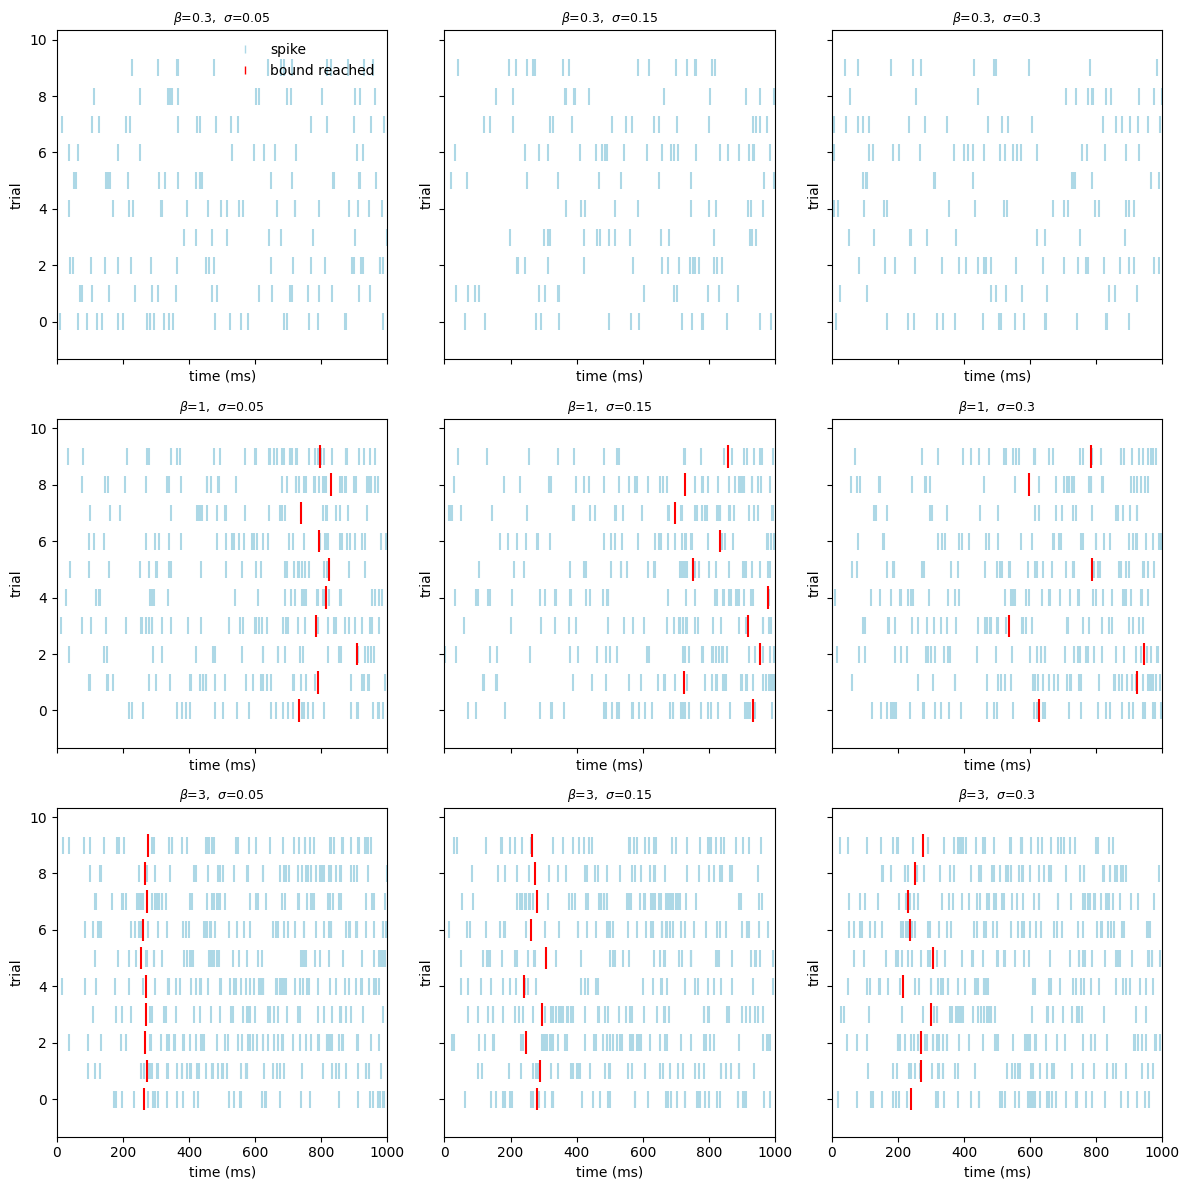

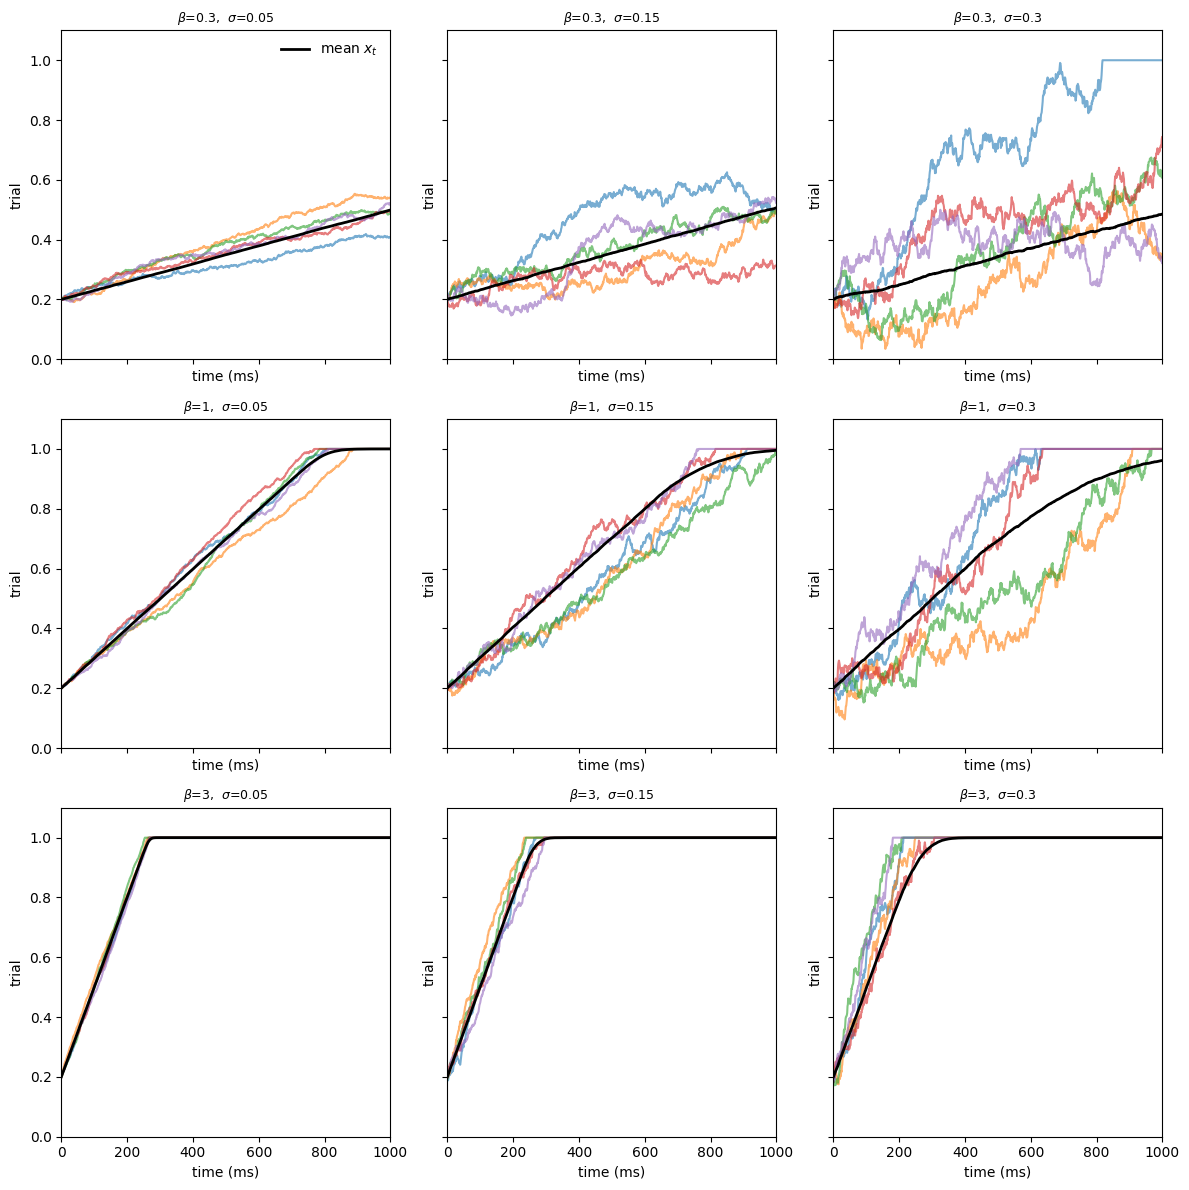

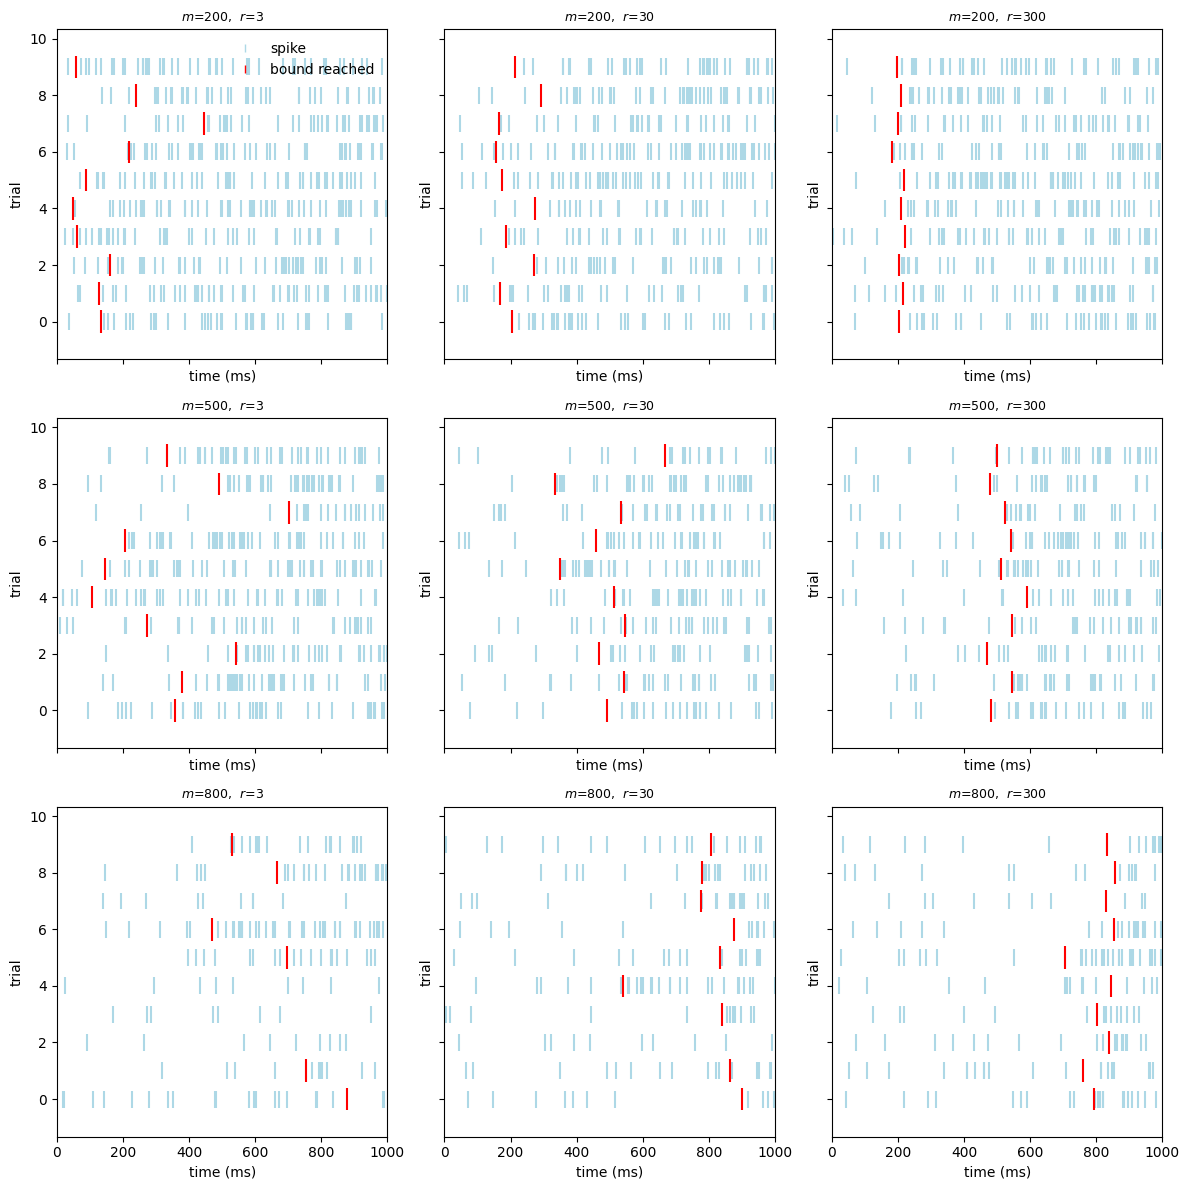

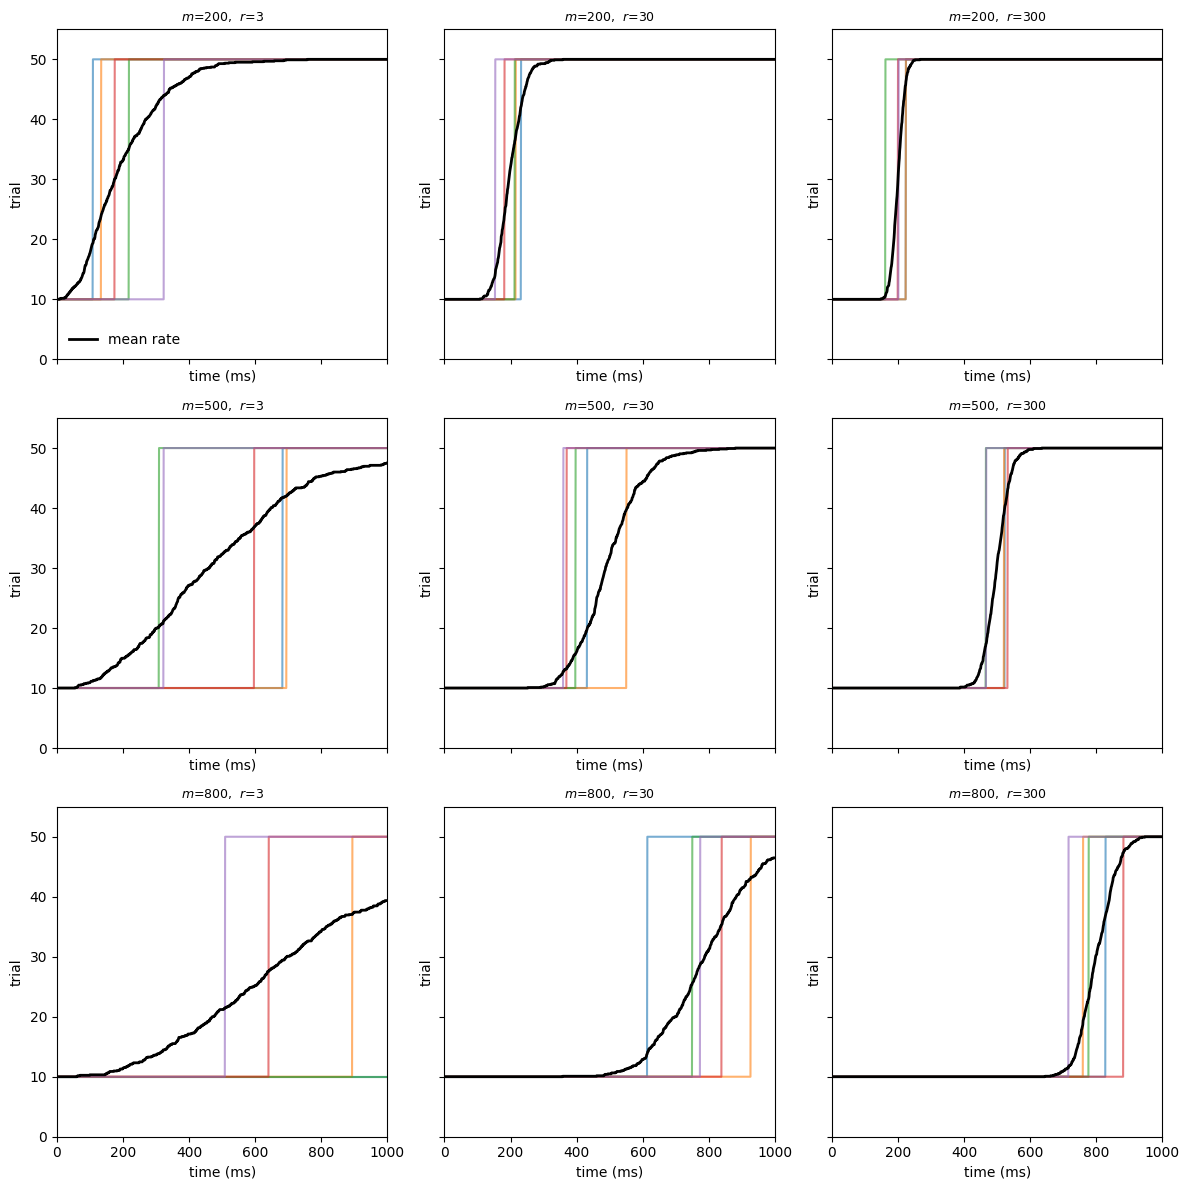

In [5]:
# Generate and display plots
ramp_raster_plot()
ramp_walk_plot()
step_raster_plot()
step_walk_plot()
plt.show()
